In [1]:
import polars as pl
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from funcs.data_import import describe_data, import_data
from funcs.feature_selection import corr_heatmap, get_correlation
from funcs.preprocessing import (
    bind_data,
    fill_na,
    fix_data,
    fix_models,
    fix_no_brand_models,
    get_dummies,
    remove_unneeded_floats,
    scale_data,
)

pl.Config.set_tbl_cols(-1)

polars.config.Config

In [2]:
df: pl.DataFrame = import_data("data/train.csv")
df_test: pl.DataFrame = import_data("data/test.csv")

'Duplicated: 0'

'Missing: '

'carID: 0/75973 (0.00%)'

'Brand: 1521/75973 (2.00%)'

'model: 1517/75973 (2.00%)'

...

model,count
str,u32
""" touareg""",9
"""i3""",1
""" CLS Class""",150
""" m3""",1
""" PROACE VERSO""",10
…,…
"""e class""",1
"""focus""",3
""" Mokka""",523


year,count
f64,u32
2023.977311,55
2023.116964,77
2007.0,123
null,1491
2008.0,158
…,…
2018.0,10304
2023.389822,53
2023.605276,39


transmission,count
str,u32
"""Automatic""",14003
"""emi-Aut""",5
"""anua""",12
"""nknown""",13
"""Manual """,16
…,…
"""EMI-AUTO""",7
"""MANUAL""",801
"""manual""",770


fuelType,count
str,u32
"""ETRO""",1
"""Hybri""",43
"""petrol""",746
"""etro""",17
"""other""",2
…,…
"""Hybrid""",2043
"""hybrid""",46
"""Other""",150


hasDamage,count
f64,u32
0.0,74425
null,1548


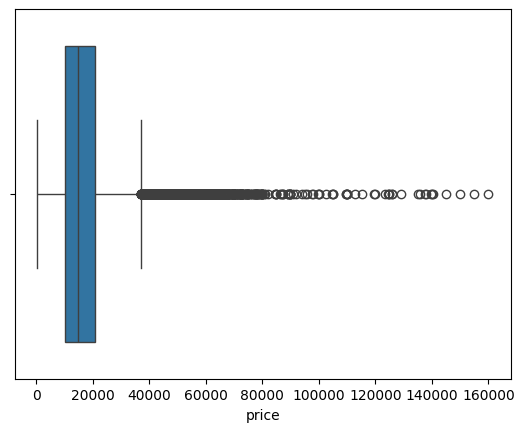

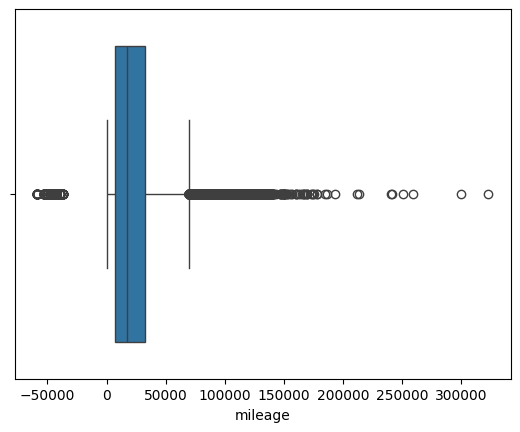

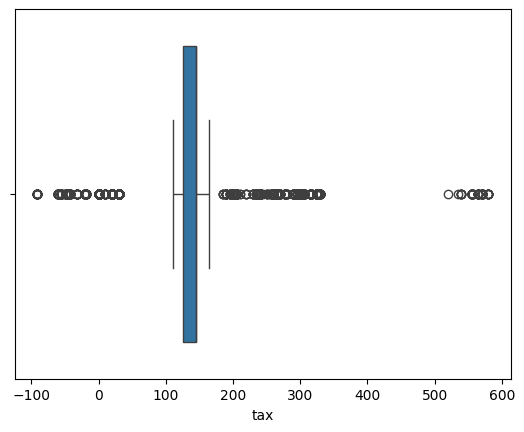

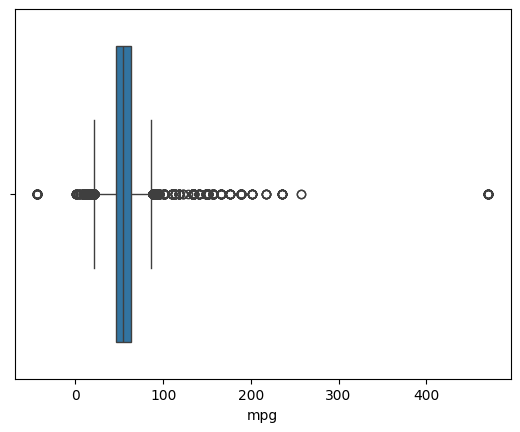

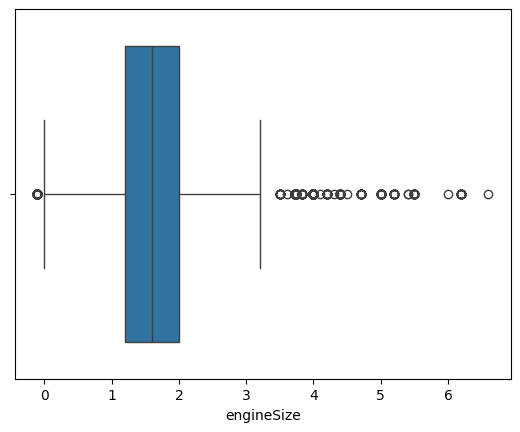

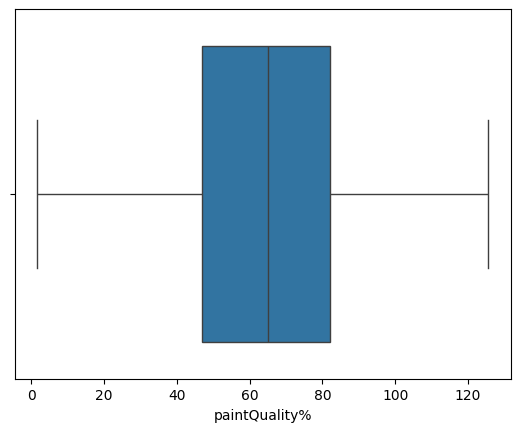

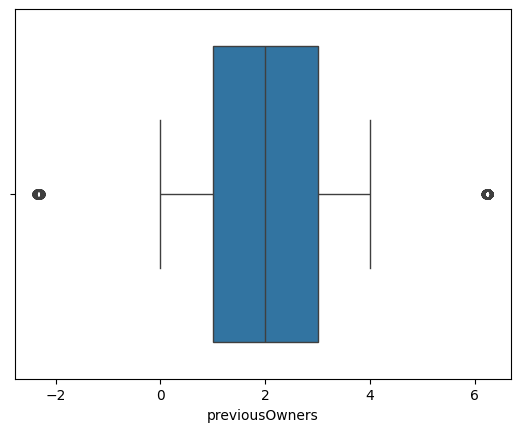

In [3]:
describe_data(
    df,
    [
        "price",
        "mileage",
        "tax",
        "mpg",
        "engineSize",
        "paintQuality%",
        "previousOwners",
    ],
    ["Brand", "model", "year", "transmission", "fuelType", "hasDamage"],
)

## Preprocessing


In [4]:
df = fix_data(
    df,
    "Brand",
    pl.col("Brand")
    .str.strip_chars()
    .str.to_lowercase()
    .str.replace("^[w]$", "vw"),
    {
        "toyota",
        "hyundai",
        "ford",
        "mercedes",
        "opel",
        "audi",
        "skoda",
        "bmw",
        "vw",
    },
)

df = fix_data(
    df,
    "transmission",
    pl.col("transmission").str.strip_chars().str.to_lowercase(),
    {"manual", "automatic", "semi-auto", "other", "unknown"},
)

df = fix_data(
    df,
    "fuelType",
    pl.col("fuelType").str.strip_chars().str.to_lowercase(),
    {"petrol", "diesel", "hybrid", "electric", "other"},
)

df = fix_models(fix_no_brand_models(fix_models(df)))

In [5]:
df_test = fix_data(
    df_test,
    "Brand",
    pl.col("Brand")
    .str.strip_chars()
    .str.to_lowercase()
    .str.replace("^[w]$", "vw"),
    {
        "toyota",
        "hyundai",
        "ford",
        "mercedes",
        "opel",
        "audi",
        "skoda",
        "bmw",
        "vw",
    },
)

df_test = fix_data(
    df_test,
    "transmission",
    pl.col("transmission").str.strip_chars().str.to_lowercase(),
    {"manual", "automatic", "semi-auto", "other", "unknown"},
)

df_test = fix_data(
    df_test,
    "fuelType",
    pl.col("fuelType").str.strip_chars().str.to_lowercase(),
    {"petrol", "diesel", "hybrid", "electric", "other"},
)

df_test = fix_models(fix_no_brand_models(fix_models(df_test)))

In [6]:
df = df.filter(~pl.col("model").str.contains("::multiple", literal=True))
# df_test = df_test.filter(
#     ~pl.col("model").str.contains("::multiple", literal=True)
# )

In [7]:
df = remove_unneeded_floats(
    df,
    ("year", "mileage", "tax", "paintQuality%", "previousOwners", "hasDamage"),
)

df_test = remove_unneeded_floats(
    df_test,
    ("year", "mileage", "tax", "paintQuality%", "previousOwners", "hasDamage"),
)

In [8]:
# THIS IS BAD, DATA LEAKAGE, TOO LAZY TO DO PROPERLY FIX RN

# df = bind_data(
#     df,
#     {
#         "mileage": {"lower": 0, "upper": 200000},
#         "tax": {"lower": 0, "upper": 350},
#         "mpg": {"lower": 20, "upper": 150},
#         "engineSize": {"lower": 0.8, "upper": 4.5},
#         "paintQuality%": {"lower": 0, "upper": 100},
#         "previousOwners": {"lower": 0, "upper": 5},
#     },
# )

# df_test = bind_data(
#     df_test,
#     {
#         "mileage": {"lower": 0, "upper": 200000},
#         "tax": {"lower": 0, "upper": 350},
#         "mpg": {"lower": 20, "upper": 150},
#         "engineSize": {"lower": 0.8, "upper": 4.5},
#         "paintQuality%": {"lower": 0, "upper": 100},
#         "previousOwners": {"lower": 0, "upper": 5},
#     },
# )

In [9]:
x = df.drop("price")
y = df.select("price")

In [10]:
x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [11]:
# x_train, x_val = fill_na(
#     x_train,
#     x_val,
#     (
#         "mileage",
#         "tax",
#         "mpg",
#         "engineSize",
#         "paintQuality%",
#         "previousOwners",
#     ),
#     bool_features=("hasDamage",),
# )

x_train, df_test = fill_na(
    x_train,
    df_test,
    (
        "mileage",
        "tax",
        "mpg",
        "engineSize",
        "paintQuality%",
        "previousOwners",
    ),
    bool_features=("hasDamage",),
)

In [12]:
# x_train, x_val = get_dummies(
#     x_train,
#     x_val,
#     (
#         "Brand",
#         "model",
#         "year",
#         "transmission",
#         "fuelType",
#     ),
# )

x_train, df_test = get_dummies(
    x_train,
    df_test,
    (
        "Brand",
        "model",
        "year",
        "transmission",
        "fuelType",
    ),
)

In [13]:
# x_train, x_val = scale_data(x_train, x_val)
x_train, df_test = scale_data(x_train, df_test)

## Feature Selection


In [14]:
corr = get_correlation(
    x_train,
    (
        "mileage",
        "tax",
        "mpg",
        "engineSize",
        "paintQuality%",
        "previousOwners",
    ),
)

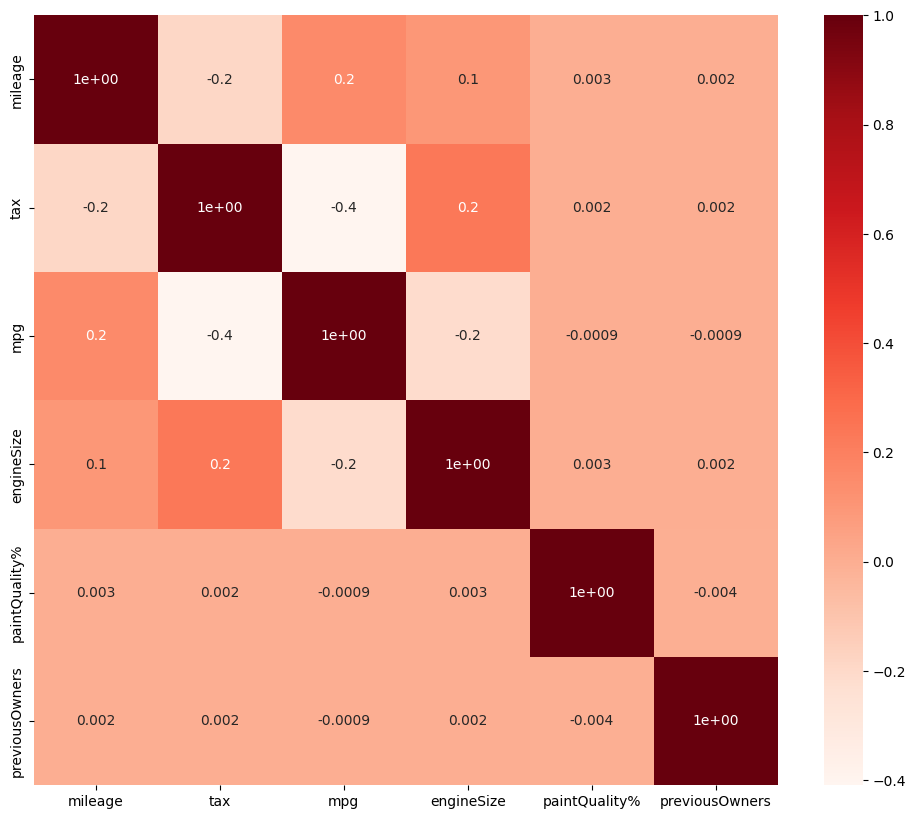

In [15]:
corr_heatmap(corr)

In [16]:
# model = LinearRegression()

# rfe(x_train, x_val, y_train, y_val, model)

In [17]:
# lasso(x_train, y_train)

In [18]:
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
from numpy import float64
from numpy.typing import NDArray

# predictions_val: NDArray[float64] = model.predict(x_val.to_pandas()).flatten()

predictions: NDArray[float64] = model.predict(df_test.to_pandas()).flatten()

In [21]:
pl.DataFrame(
    {"carID": df_test.get_column("carID"), "price": predictions}
).write_csv("data/submission.csv")